In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [4]:
df = df[["petal length (cm)", "petal width (cm)"]]

In [5]:
scaler = MinMaxScaler()
df[["petal length (cm)", "petal width (cm)"]] = scaler.fit_transform(
    df[["petal length (cm)", "petal width (cm)"]]
)

In [6]:
km = KMeans(n_clusters=3, random_state=42)
df["cluster"] = km.fit_predict(df[["petal length (cm)", "petal width (cm)"]])


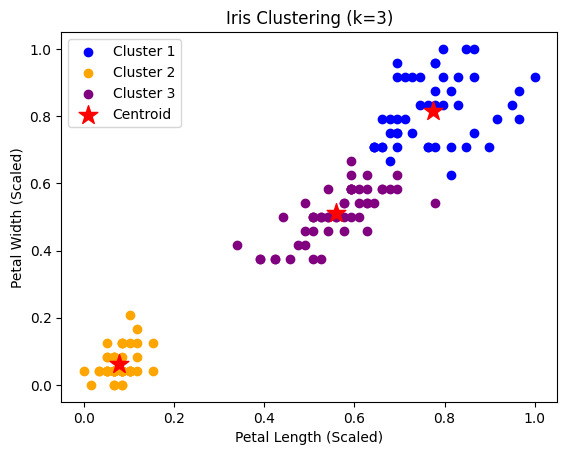

In [9]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(
    df1["petal length (cm)"], df1["petal width (cm)"], color="blue", label="Cluster 1"
)
plt.scatter(
    df2["petal length (cm)"], df2["petal width (cm)"], color="orange", label="Cluster 2"
)
plt.scatter(
    df3["petal length (cm)"], df3["petal width (cm)"], color="purple", label="Cluster 3"
)
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    color="red",
    marker="*",
    s=200,
    label="Centroid",
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.legend()
plt.title("Iris Clustering (k=3)")
plt.show()